In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [136]:
from decorator import DEF
import kagglehub

path = kagglehub.dataset_download('rohitsahoo/sales-forecasting')

print('Dataset downloaded to:', path)

Using Colab cache for faster access to the 'sales-forecasting' dataset.
Dataset downloaded to: /kaggle/input/sales-forecasting


In [137]:
import os

files = os.listdir(path)
print(f"Files in {path}:")
for file in files:
    print(file)

Files in /kaggle/input/sales-forecasting:
train.csv


In [138]:
import os
df = pd.read_csv(os.path.join(path, 'train.csv'))
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [139]:
df.head

<bound method NDFrame.head of       Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0          1  CA-2017-152156  08/11/2017  11/11/2017    Second Class   
1          2  CA-2017-152156  08/11/2017  11/11/2017    Second Class   
2          3  CA-2017-138688  12/06/2017  16/06/2017    Second Class   
3          4  US-2016-108966  11/10/2016  18/10/2016  Standard Class   
4          5  US-2016-108966  11/10/2016  18/10/2016  Standard Class   
...      ...             ...         ...         ...             ...   
9795    9796  CA-2017-125920  21/05/2017  28/05/2017  Standard Class   
9796    9797  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
9797    9798  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
9798    9799  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
9799    9800  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   

     Customer ID     Customer Name    Segment        Country             City  \
0       CG-12520       Claire Gute   Consumer  United States        Henderson   
1       CG-12520       Claire Gute   Consumer  United States        Henderson   
2       DV-13045   Darrin Van Huff  Corporate  United States      Los Angeles   
3       SO-20335    Sean O'Donnell   Consumer  United States  Fort Lauderdale   
4       SO-20335    Sean O'Donnell   Consumer  United States  Fort Lauderdale   
...          ...               ...        ...            ...              ...   
9795    SH-19975     Sally Hughsby  Corporate  United States          Chicago   
9796    CS-12490  Cindy Schnelling  Corporate  United States           Toledo   
9797    CS-12490  Cindy Schnelling  Corporate  United States           Toledo   
9798    CS-12490  Cindy Schnelling  Corporate  United States           Toledo   
9799    CS-12490  Cindy Schnelling  Corporate  United States           Toledo   

           State  Postal Code   Region       Product ID         Category  \
0       Kentucky      42420.0    South  FUR-BO-10001798        Furniture   
1       Kentucky      42420.0    South  FUR-CH-10000454        Furniture   
2     California      90036.0     West  OFF-LA-10000240  Office Supplies   
3        Florida      33311.0    South  FUR-TA-10000577        Furniture   
4        Florida      33311.0    South  OFF-ST-10000760  Office Supplies   
...          ...          ...      ...              ...              ...   
9795    Illinois      60610.0  Central  OFF-BI-10003429  Office Supplies   
9796        Ohio      43615.0     East  OFF-AR-10001374  Office Supplies   
9797        Ohio      43615.0     East  TEC-PH-10004977       Technology   
9798        Ohio      43615.0     East  TEC-PH-10000912       Technology   
9799        Ohio      43615.0     East  TEC-AC-10000487       Technology   

     Sub-Category                                       Product Name     Sales  
0       Bookcases                  Bush Somerset Collection Bookcase  261.9600  
1          Chairs  Hon Deluxe Fabric Upholstered Stacking Chairs,...  731.9400  
2          Labels  Self-Adhesive Address Labels for Typewriters b...   14.6200  
3          Tables      Bretford CR4500 Series Slim Rectangular Table  957.5775  
4         Storage                     Eldon Fold 'N Roll Cart System   22.3680  
...           ...                                                ...       ...  
9795      Binders  Cardinal HOLDit! Binder Insert Strips,Extra St...    3.7980  
9796          Art           BIC Brite Liner Highlighters, Chisel Tip   10.3680  
9797       Phones                                        GE 30524EE4  235.1880  
9798       Phones           Anker 24W Portable Micro USB Car Charger   26.3760  
9799  Accessories                SanDisk Cruzer 4 GB USB Flash Drive   10.3840  

[9800 rows x 18 columns]>

In [140]:
#1.

df.shape

(9800, 18)

In [141]:
#2.

df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [142]:
#3.

df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [143]:
df.info

<bound method DataFrame.info of       Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0          1  CA-2017-152156  08/11/2017  11/11/2017    Second Class   
1          2  CA-2017-152156  08/11/2017  11/11/2017    Second Class   
2          3  CA-2017-138688  12/06/2017  16/06/2017    Second Class   
3          4  US-2016-108966  11/10/2016  18/10/2016  Standard Class   
4          5  US-2016-108966  11/10/2016  18/10/2016  Standard Class   
...      ...             ...         ...         ...             ...   
9795    9796  CA-2017-125920  21/05/2017  28/05/2017  Standard Class   
9796    9797  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
9797    9798  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
9798    9799  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
9799    9800  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   

     Customer ID     Customer Name    Segment        Country             City  \
0       CG-12520       Claire Gute   Consumer  United States        Henderson   
1       CG-12520       Claire Gute   Consumer  United States        Henderson   
2       DV-13045   Darrin Van Huff  Corporate  United States      Los Angeles   
3       SO-20335    Sean O'Donnell   Consumer  United States  Fort Lauderdale   
4       SO-20335    Sean O'Donnell   Consumer  United States  Fort Lauderdale   
...          ...               ...        ...            ...              ...   
9795    SH-19975     Sally Hughsby  Corporate  United States          Chicago   
9796    CS-12490  Cindy Schnelling  Corporate  United States           Toledo   
9797    CS-12490  Cindy Schnelling  Corporate  United States           Toledo   
9798    CS-12490  Cindy Schnelling  Corporate  United States           Toledo   
9799    CS-12490  Cindy Schnelling  Corporate  United States           Toledo   

           State  Postal Code   Region       Product ID         Category  \
0       Kentucky      42420.0    South  FUR-BO-10001798        Furniture   
1       Kentucky      42420.0    South  FUR-CH-10000454        Furniture   
2     California      90036.0     West  OFF-LA-10000240  Office Supplies   
3        Florida      33311.0    South  FUR-TA-10000577        Furniture   
4        Florida      33311.0    South  OFF-ST-10000760  Office Supplies   
...          ...          ...      ...              ...              ...   
9795    Illinois      60610.0  Central  OFF-BI-10003429  Office Supplies   
9796        Ohio      43615.0     East  OFF-AR-10001374  Office Supplies   
9797        Ohio      43615.0     East  TEC-PH-10004977       Technology   
9798        Ohio      43615.0     East  TEC-PH-10000912       Technology   
9799        Ohio      43615.0     East  TEC-AC-10000487       Technology   

     Sub-Category                                       Product Name     Sales  
0       Bookcases                  Bush Somerset Collection Bookcase  261.9600  
1          Chairs  Hon Deluxe Fabric Upholstered Stacking Chairs,...  731.9400  
2          Labels  Self-Adhesive Address Labels for Typewriters b...   14.6200  
3          Tables      Bretford CR4500 Series Slim Rectangular Table  957.5775  
4         Storage                     Eldon Fold 'N Roll Cart System   22.3680  
...           ...                                                ...       ...  
9795      Binders  Cardinal HOLDit! Binder Insert Strips,Extra St...    3.7980  
9796          Art           BIC Brite Liner Highlighters, Chisel Tip   10.3680  
9797       Phones                                        GE 30524EE4  235.1880  
9798       Phones           Anker 24W Portable Micro USB Car Charger   26.3760  
9799  Accessories                SanDisk Cruzer 4 GB USB Flash Drive   10.3840  

[9800 rows x 18 columns]>

In [144]:
#7.

df.duplicated().any()

np.False_

In [145]:
df.duplicated().sum()

np.int64(0)

In [146]:
#8.

df["Order ID"].duplicated().any()

np.True_

In [147]:
df["Order ID"].duplicated().sum()

np.int64(4878)

In [148]:
#9.

df["Sales"].sum()

np.float64(2261536.7827000003)

In [149]:
#10.

df["Sales"].mean()

np.float64(230.7690594591837)

In [150]:
#11.

df["Sales"].min()

0.444

In [151]:
#12.

df["Customer ID"].nunique()

793

In [152]:
#13.

df.groupby("Customer ID")["Sales"].sum().idxmax()

'SM-20320'

In [153]:
df.groupby("Customer ID")["Sales"].sum().max()

25043.05

In [154]:
#14.

df.groupby("Segment")["Sales"].sum().idxmax()

'Consumer'

In [155]:
#15.

df.groupby("Category")["Sales"].sum().idxmax()


'Technology'

In [156]:
#16.

df.groupby("Sub-Category")["Sales"].sum().idxmax()


'Phones'

In [157]:
#17.

df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

,Sales
Product Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895
GBC DocuBind P400 Electric Binding System,17965.068


In [158]:
#18.

df.groupby("Region")["Sales"].sum().idxmax()

'West'

In [159]:
df.groupby("Region")["Sales"].sum().sort_values(ascending=False)


,Sales
Region,
West,710219.6845
East,669518.7260
Central,492646.9132
South,389151.4590


In [160]:
#19.

df.groupby("State")["Sales"].sum().idxmax()

'California'

In [161]:
df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(1)

,Sales
State,
California,446306.4635


In [162]:
#20.

df.groupby("City")["Sales"].sum().sort_values(ascending=False).head(5)

,Sales
City,
New York City,252462.547
Los Angeles,173420.181
Seattle,116106.322
San Francisco,109041.120
Philadelphia,108841.749


In [163]:
#21.

df["Ship Mode"].value_counts().head(1)

,count
Ship Mode,
Standard Class,5859


In [164]:
#22.

df.groupby("Ship Mode")["Sales"].sum().idxmax()


'Standard Class'

In [165]:
#23

df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

df['Shipping_Delay'] = (df['Ship Date'] - df['Order Date']).dt.days

mean_delay = df['Shipping_Delay'].mean()
print(f"Mean Shipping Delay: {mean_delay:.2f} days")

Mean Shipping Delay: 3.96 days


In [166]:
#26.

df.groupby("Segment")["Sales"].mean().sort_values(ascending=False).head(1)

,Sales
Segment,
Home Office,243.403309


In [167]:
#27.

df.groupby(["Region", "Category"])["Sales"].sum().reset_index() \
  .sort_values(["Region", "Sales"], ascending=[True, False]) \
  .drop_duplicates("Region")

,Region,Category,Sales
2,Central,Technology,168739.208
5,East,Technology,263116.527
8,South,Technology,148195.208
11,West,Technology,247404.930


In [168]:
#29.

df.groupby("Customer ID")["Sales"].sum().sort_values(ascending=False).head(10)


,Sales
Customer ID,
SM-20320,25043.050
TC-20980,19052.218
RB-19360,15117.339
TA-21385,14595.620
AB-10105,14473.571
KL-16645,14175.229
SC-20095,14142.334
HL-15040,12873.298
SE-20110,12209.438


In [169]:
#30.

df.loc[df["Sales"].idxmax(), "Product Name"]

'Cisco TelePresence System EX90 Videoconferencing Unit'

In [170]:
df["Sales"].max()

22638.48

In [171]:
#31.

(df.groupby("Product Name")["Sales"].sum() > 10000).sum()

np.int64(26)

# **Visualization**

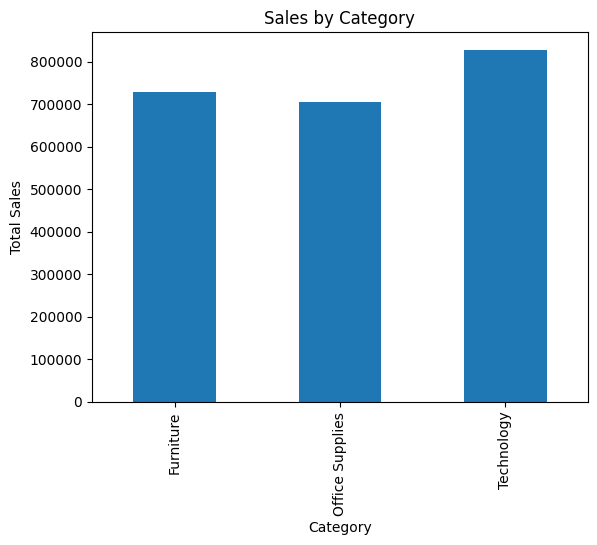

In [172]:
#1.

sales_by_category = df.groupby("Category")["Sales"].sum()

sales_by_category.plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()


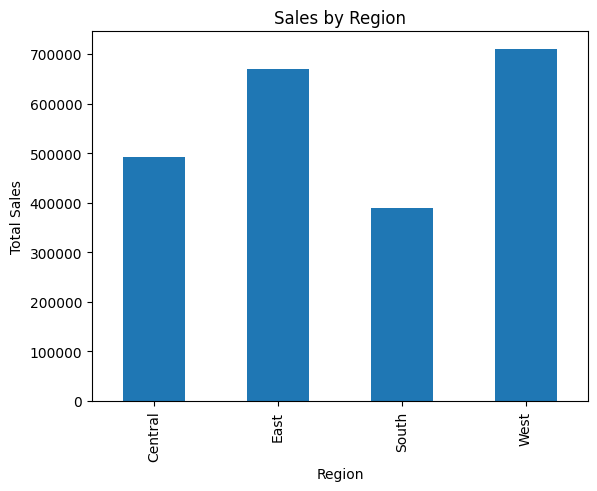

In [173]:
#2.

sales_by_region = df.groupby("Region")["Sales"].sum()

sales_by_region.plot(kind="bar")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

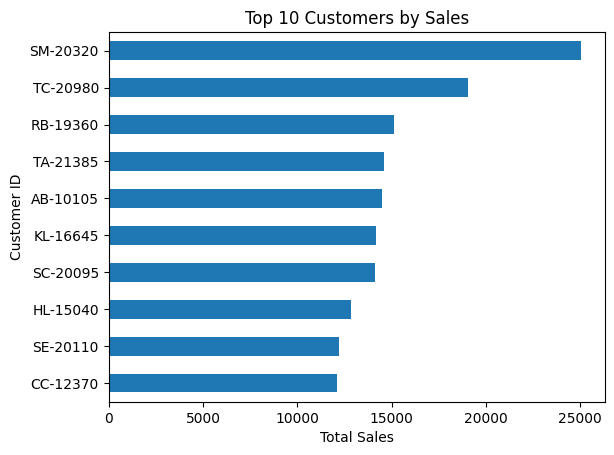

In [177]:
#5.

top_customers = (
    df.groupby("Customer ID")["Sales"]
    .sum()
    .sort_values(ascending=True)
    .tail(10)
)

top_customers.plot(kind="barh")
plt.title("Top 10 Customers by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Customer ID")
plt.show()

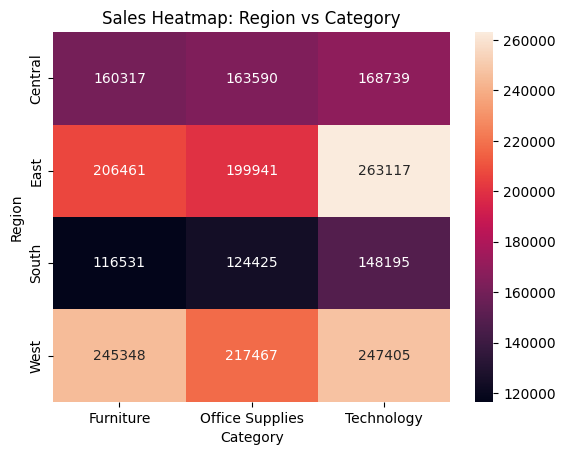

In [178]:
#6.

pivot = df.pivot_table(values="Sales", index="Region", columns="Category", aggfunc="sum")

sns.heatmap(pivot, annot=True, fmt=".0f")
plt.title("Sales Heatmap: Region vs Category")
plt.show()

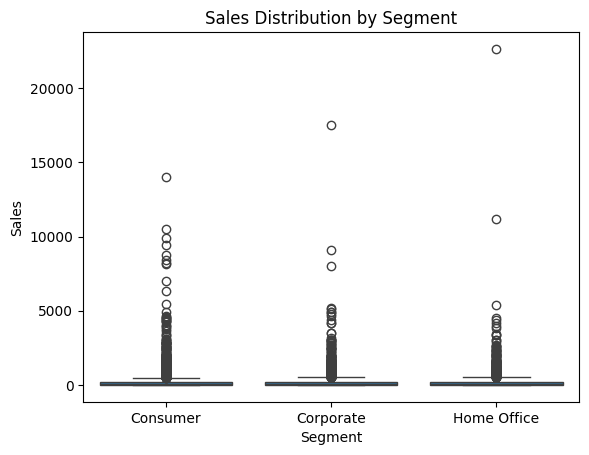

In [179]:
#7.

sns.boxplot(x="Segment", y="Sales", data=df)
plt.title("Sales Distribution by Segment")
plt.show()


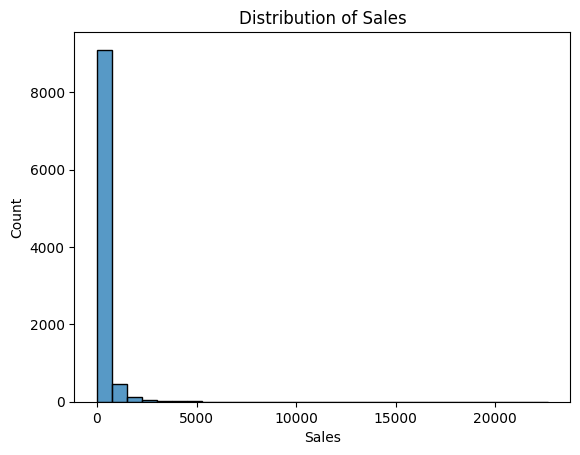

In [180]:
#8.

sns.histplot(df["Sales"], bins=30)
plt.title("Distribution of Sales")
plt.show()

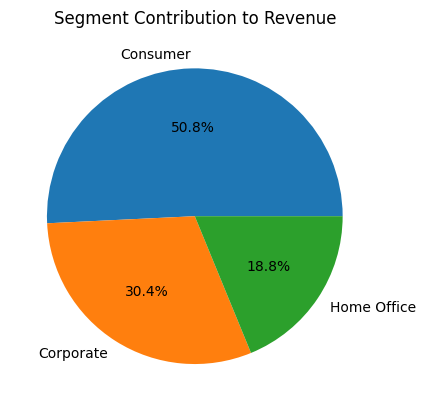

In [181]:
#9.

segment_sales = df.groupby("Segment")["Sales"].sum()

plt.pie(segment_sales, labels=segment_sales.index, autopct="%1.1f%%")
plt.title("Segment Contribution to Revenue")
plt.show()

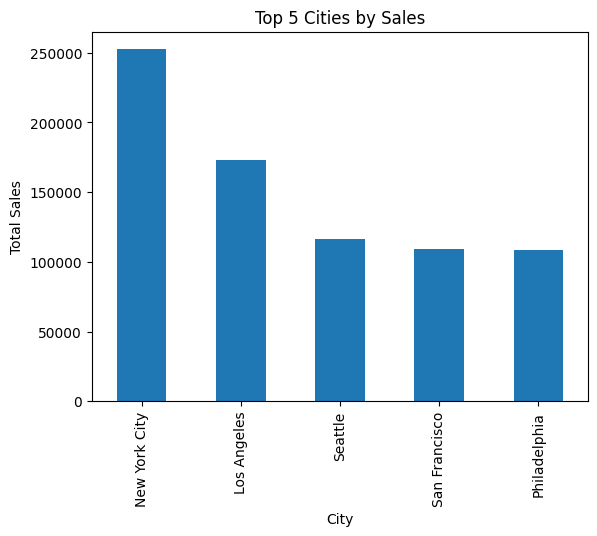

In [182]:
#10.

top_cities = (
    df.groupby("City")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

top_cities.plot(kind="bar")
plt.title("Top 5 Cities by Sales")
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.show()